<a href="https://colab.research.google.com/github/heoconngoc/Ruled-Based-A.I.-and-Deep-Learning/blob/main/Random_MCTS_vs_UCT_MCTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Random MCTS vs UCT MCTS on Connect Four

## Goal
This notebook implements two versions of Monte Carlo Tree Search (MCTS) for Connect Four:

1. **Random-Selection MCTS**
   - During tree traversal, child selection is random.
   - Simulation (rollout) is also random.

2. **UCT MCTS**
   - During tree traversal, child selection uses the UCT formula.
   - Simulation remains random.

This notebook is designed to help understand the impact of using a better **selection policy** while keeping the rest of the MCTS pipeline the same.

- The four MCTS phases:
  - Select
  - Expand
  - Simulate
  - Backpropagate
- UCT is better than random tree traversal


In [1]:
# ============================================================
# Section 1: Imports and global settings
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Connect Four Environment

We use the standard 6x7 Connect Four board.

### Representation
- `1`  = player 1
- `-1` = player 2
- `0`  = empty cell

### Rules
- Players drop pieces into columns
- A piece falls to the lowest available row
- The game ends when:
  - one player gets 4 in a row, or
  - the board is full


In [2]:
# ============================================================
# Section 2: Connect Four environment
# ============================================================

class ConnectFour:
    ROWS = 6
    COLS = 7

    def __init__(self):
        self.board = np.zeros((self.ROWS, self.COLS), dtype=np.int8)
        self.current_player = 1
        self.winner = None
        self.last_move = None

    def clone(self):
        env = ConnectFour()
        env.board = self.board.copy()
        env.current_player = self.current_player
        env.winner = self.winner
        env.last_move = self.last_move
        return env

    def legal_moves(self):
        return [c for c in range(self.COLS) if self.board[0, c] == 0]

    def apply_move(self, col):
        if col not in self.legal_moves():
            raise ValueError(f"Illegal move: {col}")

        for row in range(self.ROWS - 1, -1, -1):
            if self.board[row, col] == 0:
                self.board[row, col] = self.current_player
                self.last_move = (row, col)
                break

        if self._check_winner(row, col, self.current_player):
            self.winner = self.current_player
        elif len(self.legal_moves()) == 0:
            self.winner = 0  # draw

        self.current_player *= -1

    def is_terminal(self):
        return self.winner is not None

    def result_for_player(self, player):
        """
        Returns:
            +1 if 'player' wins
            -1 if 'player' loses
             0 if draw
        """
        if self.winner == player:
            return 1
        elif self.winner == -player:
            return -1
        return 0

    def _check_winner(self, row, col, player):
        directions = [(1, 0), (0, 1), (1, 1), (1, -1)]

        for dr, dc in directions:
            count = 1

            r, c = row + dr, col + dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r += dr
                c += dc

            r, c = row - dr, col - dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r -= dr
                c -= dc

            if count >= 4:
                return True

        return False

    def render(self):
        display_board = self.board.copy()
        print(display_board)
        print("Current player:", self.current_player)

    def pretty_print(self):
        symbols = {1: "X", -1: "O", 0: "."}
        print("\n".join(" ".join(symbols[x] for x in row) for row in self.board))
        print("0 1 2 3 4 5 6")
        print(f"Current player: {'X' if self.current_player == 1 else 'O'}")

In [3]:
# ============================================================
# Section 3: Quick environment test
# ============================================================

env = ConnectFour()
env.apply_move(3)
env.apply_move(3)
env.apply_move(2)
env.apply_move(2)
env.apply_move(1)
env.apply_move(1)
env.apply_move(0)  # player 1 should win diagonally or horizontally depending on sequence
env.pretty_print()
print("Winner:", env.winner)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O O O . . .
X X X X . . .
0 1 2 3 4 5 6
Current player: O
Winner: 1


## MCTS Node Design

Each node stores:
- the game state
- parent / children
- move used to reach the node
- visit count
- total value
- list of untried moves

### Value convention
We store values from the perspective of the **player to move at that node**.

This is convenient for two-player zero-sum games because:
- when we move to a child, the perspective flips
- during backpropagation, we simply negate the value

In [4]:
# ============================================================
# Section 4: MCTS node
# ============================================================

class MCTSNode:
    def __init__(self, state, parent=None, move=None):
        self.state = state
        self.parent = parent
        self.move = move
        self.children = {}  # move -> child node
        self.untried_moves = state.legal_moves()
        self.visits = 0
        self.value_sum = 0.0

    @property
    def q(self):
        if self.visits == 0:
            return 0.0
        return self.value_sum / self.visits

    def is_fully_expanded(self):
        return len(self.untried_moves) == 0

    def add_child(self, move, child_state):
        child = MCTSNode(state=child_state, parent=self, move=move)
        self.children[move] = child
        self.untried_moves.remove(move)
        return child

## Random rollout policy

This rollout policy simply samples legal moves uniformly at random until the game ends.

In [5]:
# ============================================================
# Section 5: Random rollout
# ============================================================

def random_rollout(env):
    rollout_env = env.clone()

    while not rollout_env.is_terminal():
        move = random.choice(rollout_env.legal_moves())
        rollout_env.apply_move(move)

    # Return result from the perspective of the player to move at the input state
    return rollout_env.result_for_player(env.current_player)


## Random-Selection MCTS

This variant uses random child selection during tree traversal.

Pipeline:
1. **Select** randomly among existing children
2. **Expand** one new child if possible
3. **Simulate** with random rollout
4. **Backpropagate**

In [6]:
# ============================================================
# Section 6: Random-Selection MCTS
# ============================================================

class RandomSelectionMCTS:
    def __init__(self, num_simulations=200):
        self.num_simulations = num_simulations

    def select_child(self, node):
        return random.choice(list(node.children.values()))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            # 1) Selection
            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            # 2) Expansion
            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                next_state = node.state.clone()
                next_state.apply_move(move)
                node = node.add_child(move, next_state)

            # 3) Simulation
            value = random_rollout(node.state)

            # 4) Backpropagation
            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        best_move = max(root.children.items(), key=lambda x: x[1].visits)[0]
        return best_move, root


## UCT MCTS

This variant uses the **Upper Confidence Bound for Trees (UCT)** formula:

\[
\text{UCT}(child) = -Q(child) + c \cdot \sqrt{\frac{\ln(N_{parent} + 1)}{N_{child}}}
\]

Why `-Q(child)`?
- `Q(child)` is from the perspective of the player to move **at the child**
- but when choosing a child, we want the value from the perspective of the **current node**
- since the game is zero-sum, we negate the child value

### Interpretation
- exploitation: choose moves with high estimated value
- exploration: still try less-visited children

In [8]:
# ============================================================
# Section 7: UCT MCTS
# ============================================================

class UCTMCTS:
    def __init__(self, num_simulations=200, c=1.4):
        self.num_simulations = num_simulations
        self.c = c

    def uct_score(self, parent, child):
        if child.visits == 0:
            return float("inf")
        exploit = -child.q
        explore = self.c * math.sqrt(math.log(parent.visits + 1) / child.visits)
        return exploit + explore

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.uct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            # 1) Selection
            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            # 2) Expansion
            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                next_state = node.state.clone()
                next_state.apply_move(move)
                node = node.add_child(move, next_state)

            # 3) Simulation
            value = random_rollout(node.state)

            # 4) Backpropagation
            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        best_move = max(root.children.items(), key=lambda x: x[1].visits)[0]
        return best_move, root

    def get_root_visit_distribution(self, root):
        counts = np.zeros(ConnectFour.COLS, dtype=np.float32)
        for move, child in root.children.items():
            counts[move] = child.visits
        if counts.sum() > 0:
            counts /= counts.sum()
        return counts

## Agent wrappers

We create lightweight agent classes so that different methods can play against each other.

In [9]:
# ============================================================
# Section 8: Agent wrappers
# ============================================================

class RandomAgent:
    def choose_move(self, env):
        return random.choice(env.legal_moves())

class RandomSelectionMCTSAgent:
    def __init__(self, num_simulations=200):
        self.mcts = RandomSelectionMCTS(num_simulations=num_simulations)

    def choose_move(self, env):
        move, _ = self.mcts.search(env)
        return move

class UCTMCTSAgent:
    def __init__(self, num_simulations=200, c=1.4):
        self.mcts = UCTMCTS(num_simulations=num_simulations, c=c)

    def choose_move(self, env):
        move, _ = self.mcts.search(env)
        return move

## Match simulation

The next cell lets two agents play many games and returns:
- wins for agent 1
- wins for agent 2
- draws

In [10]:
# ============================================================
# Section 9: Match simulation
# ============================================================

def play_game(agent1, agent2, verbose=False):
    env = ConnectFour()

    while not env.is_terminal():
        if env.current_player == 1:
            move = agent1.choose_move(env.clone())
        else:
            move = agent2.choose_move(env.clone())
        env.apply_move(move)

        if verbose:
            env.pretty_print()
            print("-" * 30)

    return env.winner

def evaluate_agents(agent1, agent2, num_games=20):
    results = {1: 0, -1: 0, 0: 0}

    for g in range(num_games):
        if g % 2 == 0:
            winner = play_game(agent1, agent2, verbose=False)
            results[winner] += 1
        else:
            # Swap starting positions for fairness
            winner = play_game(agent2, agent1, verbose=False)
            if winner == 1:
                results[-1] += 1
            elif winner == -1:
                results[1] += 1
            else:
                results[0] += 1

    return results

## First experiment

We compare:
- Random agent
- Random-Selection MCTS
- UCT MCTS

In [11]:
# ============================================================
# Section 10: First experiment
# ============================================================

random_agent = RandomAgent()
random_mcts_agent = RandomSelectionMCTSAgent(num_simulations=150)
uct_agent = UCTMCTSAgent(num_simulations=150, c=1.4)

print("Random MCTS vs Random Agent")
print(evaluate_agents(random_mcts_agent, random_agent, num_games=20))

print("UCT MCTS vs Random Agent")
print(evaluate_agents(uct_agent, random_agent, num_games=20))

print("UCT MCTS vs Random-Selection MCTS")
print(evaluate_agents(uct_agent, random_mcts_agent, num_games=20))

Random MCTS vs Random Agent
{1: 9, -1: 11, 0: 0}
UCT MCTS vs Random Agent
{1: 20, -1: 0, 0: 0}
UCT MCTS vs Random-Selection MCTS
{1: 20, -1: 0, 0: 0}


## Experiment with different simulation budgets

A strong MCTS implementation usually gets better with more simulations.

We test different budgets and record the win rate of UCT MCTS against Random-Selection MCTS.

In [12]:
# ============================================================
# Section 11: Simulation budget experiment
# ============================================================

budgets = [50, 100, 200, 400]
uct_win_rates = []

for sims in budgets:
    agent_a = UCTMCTSAgent(num_simulations=sims, c=1.4)
    agent_b = RandomSelectionMCTSAgent(num_simulations=sims)

    results = evaluate_agents(agent_a, agent_b, num_games=20)
    win_rate = results[1] / 20.0
    uct_win_rates.append(win_rate)

    print(f"Simulations={sims}, results={results}, win_rate={win_rate:.2f}")

Simulations=50, results={1: 19, -1: 1, 0: 0}, win_rate=0.95
Simulations=100, results={1: 20, -1: 0, 0: 0}, win_rate=1.00
Simulations=200, results={1: 20, -1: 0, 0: 0}, win_rate=1.00
Simulations=400, results={1: 20, -1: 0, 0: 0}, win_rate=1.00


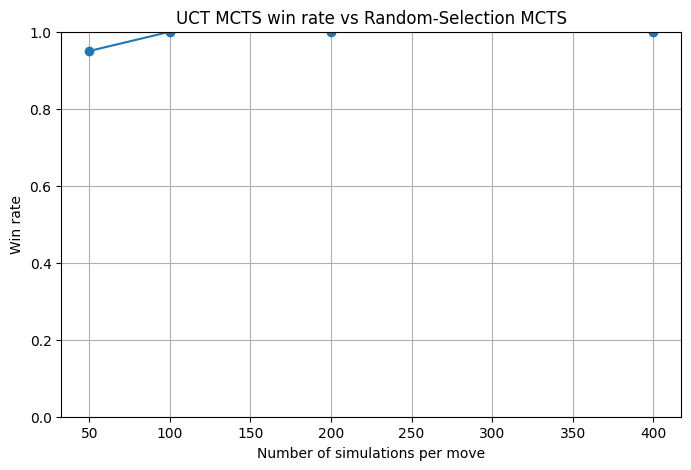

In [13]:
# ============================================================
# Section 12: Plot results
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(budgets, uct_win_rates, marker='o')
plt.title("UCT MCTS win rate vs Random-Selection MCTS")
plt.xlabel("Number of simulations per move")
plt.ylabel("Win rate")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . X X O . .
0 1 2 3 4 5 6
Current player: X


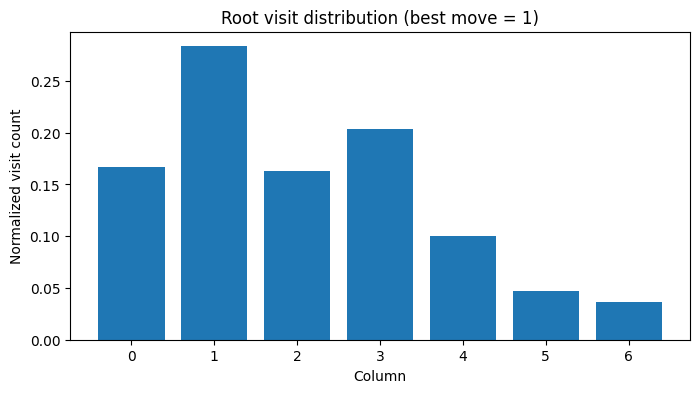

In [14]:
# ============================================================
# Section 13: Root visit distribution example
# ============================================================

env = ConnectFour()
env.apply_move(3)
env.apply_move(3)
env.apply_move(2)
env.apply_move(4)

env.pretty_print()

uct = UCTMCTS(num_simulations=300, c=1.4)
# Exploration coeffienct = 1.4

best_move, root = uct.search(env)

visit_dist = uct.get_root_visit_distribution(root)

plt.figure(figsize=(8, 4))
plt.bar(range(ConnectFour.COLS), visit_dist)
plt.title(f"Root visit distribution (best move = {best_move})")
plt.xlabel("Column")
plt.ylabel("Normalized visit count")
plt.show()

## Conclusion

This notebook demonstrated that:
- MCTS structure matters
- better **selection** leads to stronger play
- UCT improves over random traversal by balancing exploration and exploitation